In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import os

from scipy.integrate import trapezoid
from scipy.stats import linregress

from amocatlas import read
from correlation_trends import geostrophy, filters

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

#MOC = transports.MOC
#TRANS_FC = transports.TRANS_FC
#TRANS_EKMAN = transports.TRANS_FC
TRANS_UMO = transports.TRANS_UMO

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)
# 26N overturning in density coordinates: MOC_SIGMA0
#mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)
# 47N NOAC overturning (monthly): MOC_SIGMA0
#noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity



In [4]:
# defining salinity and temperature arrays at the boundaries for further calculation

PSAL_WEST = ts.PSAL_WEST
PSAL_EAST = ts.PSAL_EAST
T_WEST = ts.TEMP_WEST
T_EAST = ts.TEMP_EAST

# define the vertical pressure levels
p = ts.PRESSURE

# define the coriolis parameter at 26°N
f = 2 * 7.292e-5 * np.sin(26 / 180 * np.pi)

In [5]:
# converting to TEOS-10 units
# check if the data files exist, if they dont exist, 
# convert again and write .npy files for them to make the calculation quicker (takes around 5 mins for me locally)
if os.path.isfile("../data/TS_WEST.npy") and os.path.isfile("../data/TS_EAST.npy"):
    TS_WEST = np.load("../data/TS_WEST.npy")
    TS_EAST = np.load("../data/TS_EAST.npy")
else:
    # create data directory in the repo if it doesnt exist (not necessary with my gitignore settings but still cleaner)
    os.makedirs("../data", exist_ok = True) 
    TS_WEST = geostrophy.to_teos10(temp=T_WEST,salt = PSAL_WEST,pres = p,lat = 26.52,lon = -76.74)
    np.save("../data/TS_WEST.npy",TS_WEST)
    TS_EAST = geostrophy.to_teos10(temp=T_EAST,salt = PSAL_EAST,pres = p,lat = 26.99,lon = -16.23)
    np.save("../data/TS_EAST.npy",TS_EAST)

In [10]:
#using reference pressure pref, calculate dynamic height
pref = 4820.0 #dBar
dynamic_height_west_nan = geostrophy.dynamic_height(TS_WEST[0].T,TS_WEST[1].T,p,pref) # have to transpose the arrays, otherwise the pressure is on the wrong axis
dynamic_height_east_nan = geostrophy.dynamic_height(TS_EAST[0].T,TS_EAST[1].T,p,pref)
# linearly interpolate the dynamic height profile time series
dynamic_height_west = geostrophy._fill_profiles(dynamic_height_west_nan,p)
dynamic_height_east = geostrophy._fill_profiles(dynamic_height_east_nan,p)

In [11]:
#difference the dynamics heights to get zonally-integrated geostrophic transport per unit depth 
# (EAST MINUS WEST, is just convention and, positive is here northward transport)
#fix the calculation by properly calculating streamfunction from dynamic height
psi_difference = dynamic_height_east - dynamic_height_west
#get transport
delta_x = 6.37e6*np.cos(np.deg2rad(26))*np.deg2rad(76.74-16.23) # not sure we need it 

#m^2/s zonally-integrated geostrophic transport per unit depth
thermal_wind = psi_difference / f 

#integrate until 1100 m (or dbar for that matter)
transport = trapezoid(y = thermal_wind[:55,:],x = p.values[:55],axis = 0) / 1e6 # converted to Sverdrup unit

In [12]:
# introduce 10 day lowpass to match RAPID filtering
filtered_transport_geostrophy = filters.tukey_lowpass(transport,window = 20)

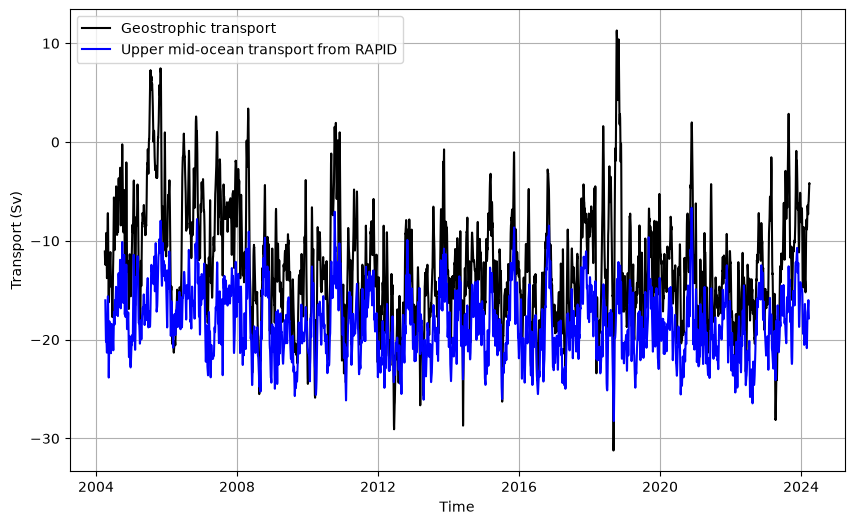

In [13]:
plt.figure(figsize=[10,6])
plt.plot(TRANS_UMO["TIME"],filtered_transport_geostrophy, color ="k",label = "Geostrophic transport")
plt.plot(TRANS_UMO["TIME"],TRANS_UMO,color = "blue", label = "Upper mid-ocean transport from RAPID")
plt.grid()
plt.xlabel("Time")
plt.ylabel("Transport (Sv)")
plt.legend()
plt.savefig(figpath + "UMO_geostrophy.png")

In [64]:
# we skip the first and last 10 time data points as they are removed in the 10 day lowpass filtering
finite_transport = np.isfinite(TRANS_UMO.values)
r = np.corrcoef(filtered_transport_geostrophy[finite_transport], TRANS_UMO.values[finite_transport])
r_unfiltered = np.corrcoef(transport[finite_transport], TRANS_UMO.values[finite_transport])

regression_line = linregress(filtered_transport_geostrophy[finite_transport],TRANS_UMO[finite_transport])
print(f"The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is {r[0,1]:.3f}")
print(f"The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is {r_unfiltered[0,1]:.3f}")

The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is 0.774
The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is 0.752


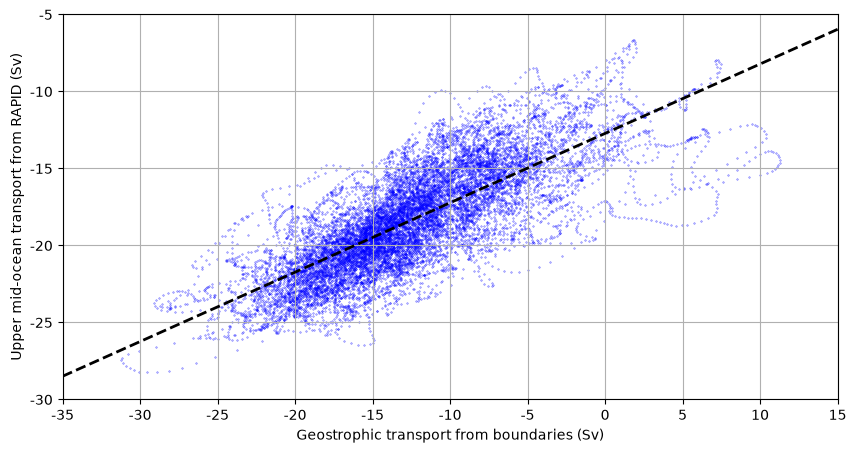

In [65]:
plt.figure(figsize=(10,5))
plt.scatter(filtered_transport_geostrophy, TRANS_UMO, c = "blue", marker = "x", s = 1, alpha = 0.3)
plt.plot(
    np.arange(-35,20,5),
    np.arange(-35,20,5)*regression_line.slope + regression_line.intercept, 
    ls = "--",
    color = "k",
    lw = 2
    )
plt.xlabel("Geostrophic transport from boundaries (Sv)")
plt.ylabel("Upper mid-ocean transport from RAPID (Sv)")
plt.grid()
plt.ylim(-30,-5)
plt.xlim(-35,15)
plt.xticks(np.arange(-35,20,5),np.arange(-35,20,5))
plt.yticks(np.arange(-30,0,5),np.arange(-30,0,5))
plt.savefig(figpath + "scatter_geostrophy_UMO.png")
plt.show()